In [1]:
import sys
print(sys.version)

3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, silhouette_score, davies_bouldin_score
from scipy.optimize import linear_sum_assignment

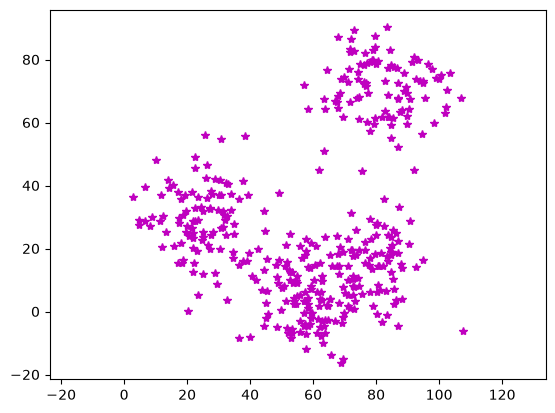

In [3]:
# Generate Data - two means
mean1 = [np.random.randint(100), np.random.randint(100)]
mean2 = [np.random.randint(100), np.random.randint(100)]
mean3 = [np.random.randint(100), np.random.randint(100)]
mean4 = [np.random.randint(100), np.random.randint(100)]

#make diagonal covariance
cov =[[100,0], [0,100]]

x1, y1 = np.random.multivariate_normal(mean1, cov, 100).T
x2, y2 = np.random.multivariate_normal(mean2, cov, 100).T
x3, y3 = np.random.multivariate_normal(mean3, cov, 100).T
x4, y4 = np.random.multivariate_normal(mean4, cov, 100).T

x = np.concatenate((x1, x2, x3, x4))
y = np.concatenate((y1, y2, y3, y4))

plt.plot(x, y, 'm*')
plt.axis('equal')
plt.show()

In [4]:
X = np.array(list(zip(x, y)))

In [5]:
#make k-means model
kmeans = KMeans(n_clusters = 4)

In [6]:
# fit model to data
kmeans.fit(X)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](4, 2)",

In [7]:
centroids = kmeans.cluster_centers_
labels = kmeans.labels_

print(labels)
print(centroids)

[1 1 1 1 3 1 1 1 1 3 2 3 1 1 1 1 1 1 1 1 1 1 0 3 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 3 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 3 3 1 1
 1 1 1 2 1 1 3 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 3 1 1 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 3 3 3 3 3 1 3 3 3 3 3 1 3 3 3 3 3 3 3 1 3 3
 1 3 3 3 3 1 3 3 3 1 3 1 3 3 3 3 1 3 3 1 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 1 3
 3 3 1 3 1 3 1 1 3 3 3 3 3 3 3 1 1 3 3 3 3 3 3 3 3 3 3 3 3 3 3 1 3 3 3 1 1
 1 3 3 3 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]
[[81.7373926  70.59988245]
 [56.35453542  3.92853136]
 [24.843122   29.39472343]
 [78.87284513 14.80977799]]


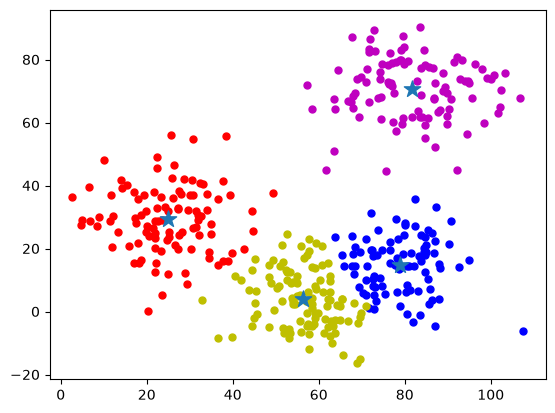

In [8]:
colors = ["m.", "y.", "r.", "b."]

for i in range(len(X)):
    plt.plot(X[i][0], X[i][1], colors[labels[i]], markersize = 10)

plt.scatter(centroids[:, 0], centroids[:, 1], marker="*", s=150, zorder=10)

plt.show()

In [9]:
print(centroids)
print(mean1, mean2, mean3, mean4)

[[81.7373926  70.59988245]
 [56.35453542  3.92853136]
 [24.843122   29.39472343]
 [78.87284513 14.80977799]]
[56, 5] [81, 71] [75, 15] [27, 30]


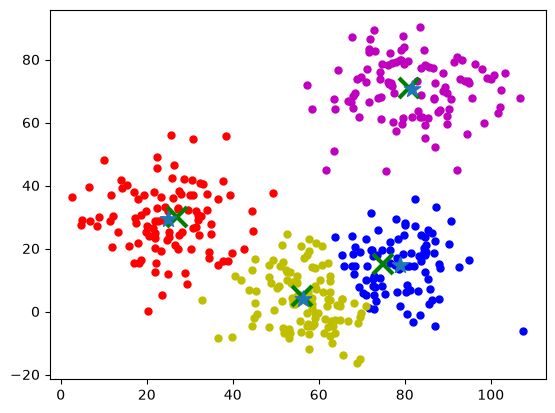

In [10]:
colors = ["m.", "y.", "r.", "b."]

for i in range(len(X)):
    plt.plot(X[i][0], X[i][1], colors[labels[i]], markersize=10)

# KMeans centroids as stars
plt.scatter(centroids[:, 0], centroids[:, 1], marker="*", s=150, zorder=10)

# mean1 and mean2 as green x markers
plt.plot(mean1[0], mean1[1], "gx", markersize=15, markeredgewidth=3)
plt.plot(mean2[0], mean2[1], "gx", markersize=15, markeredgewidth=3)
plt.plot(mean3[0], mean3[1], "gx", markersize=15, markeredgewidth=3)
plt.plot(mean4[0], mean4[1], "gx", markersize=15, markeredgewidth=3)

plt.show()

In [11]:
# Original generated the data
true_labels = np.array(
    [0] * 100 +
    [1] * 100 +
    [2] * 100 +
    [3] * 100
)

# KMeans predicted labels
predicted_labels = kmeans.labels_

# Create confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Find best matching between KMeans cluster labels and original labels
row_ind, col_ind = linear_sum_assignment(-cm)

# Build label mapping
label_mapping = {}

for true_label, predicted_label in zip(row_ind, col_ind):
    label_mapping[predicted_label] = true_label

# Apply mapping to predictions
mapped_predictions = np.array([label_mapping[label] for label in predicted_labels])

# Accuracy
accuracy = accuracy_score(true_labels, mapped_predictions)

print("Cluster label mapping:")
print(label_mapping)

print("\nAccuracy:")
print(accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(true_labels, mapped_predictions))

print("\nClassification Report:")
print(classification_report(true_labels, mapped_predictions))

Cluster label mapping:
{np.int64(1): np.int64(0), np.int64(0): np.int64(1), np.int64(3): np.int64(2), np.int64(2): np.int64(3)}

Accuracy:
0.92

Confusion Matrix:
[[ 88   1   9   2]
 [  0 100   0   0]
 [ 20   0  80   0]
 [  0   0   0 100]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.88      0.85       100
           1       0.99      1.00      1.00       100
           2       0.90      0.80      0.85       100
           3       0.98      1.00      0.99       100

    accuracy                           0.92       400
   macro avg       0.92      0.92      0.92       400
weighted avg       0.92      0.92      0.92       400



In [12]:
#experiment with k

for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
    kmeans.fit(X)

    predicted_labels = kmeans.labels_

    cm = confusion_matrix(true_labels, predicted_labels)

    row_ind, col_ind = linear_sum_assignment(-cm)

    label_mapping = {}

    for true_label, predicted_label in zip(row_ind, col_ind):
        label_mapping[predicted_label] = true_label

    mapped_predictions = np.array([
        label_mapping.get(label, -1) for label in predicted_labels
    ])

    accuracy = accuracy_score(true_labels, mapped_predictions)

    print("k =", k)
    print("Accuracy:", accuracy)
    print("Confusion matrix:")
    print(confusion_matrix(true_labels, mapped_predictions))
    print("-" * 40)

k = 2
Accuracy: 0.5
Confusion matrix:
[[100   0   0   0]
 [  0 100   0   0]
 [ 98   2   0   0]
 [100   0   0   0]]
----------------------------------------
k = 3
Accuracy: 0.75
Confusion matrix:
[[  0   1  95   4]
 [  0 100   0   0]
 [  0   0 100   0]
 [  0   0   0 100]]
----------------------------------------
k = 4
Accuracy: 0.92
Confusion matrix:
[[ 88   1   9   2]
 [  0 100   0   0]
 [ 20   0  80   0]
 [  0   0   0 100]]
----------------------------------------
k = 5
Accuracy: 0.82
Confusion matrix:
[[ 60   0   7   1  32]
 [  0 100   0   0   0]
 [ 13   0  78   0   9]
 [  0   0   0  90  10]
 [  0   0   0   0   0]]
----------------------------------------
k = 6
Accuracy: 0.6975
Confusion matrix:
[[61  0  6  1 32  0]
 [ 0 50  0  0  0 50]
 [13  0 78  0  9  0]
 [ 0  0  0 90 10  0]
 [ 0  0  0  0  0  0]
 [ 0  0  0  0  0  0]]
----------------------------------------
k = 7
Accuracy: 0.585
Confusion matrix:
[[57  0  8  1 34  0  0]
 [ 0 50  0  0  0  0 50]
 [13  0 78  0  9  0  0]
 [ 0  0  0 49

In [13]:
for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
    kmeans.fit(X)

    labels = kmeans.labels_

    inertia = kmeans.inertia_
    silhouette = silhouette_score(X, labels)
    davies_bouldin = davies_bouldin_score(X, labels)

    print("k =", k)
    print("Inertia:", inertia)
    print("Silhouette score:", silhouette)
    print("Davies-Bouldin score:", davies_bouldin)
    print("-" * 40)

k = 2
Inertia: 244128.74741741177
Silhouette score: 0.5467253045904086
Davies-Bouldin score: 0.6199168022803246
----------------------------------------
k = 3
Inertia: 98732.28762118556
Silhouette score: 0.5961440611550857
Davies-Bouldin score: 0.5579785891689819
----------------------------------------
k = 4
Inertia: 68802.97044009717
Silhouette score: 0.5289902102427853
Davies-Bouldin score: 0.6681534234903008
----------------------------------------
k = 5
Inertia: 60381.344427106065
Silhouette score: 0.48753148457466994
Davies-Bouldin score: 0.7430671559774971
----------------------------------------
k = 6
Inertia: 51601.62231123685
Silhouette score: 0.41740350638865564
Davies-Bouldin score: 0.8901867230332532
----------------------------------------
k = 7
Inertia: 45123.62897752848
Silhouette score: 0.38089107381077625
Davies-Bouldin score: 0.9755543604406162
----------------------------------------
k = 8
Inertia: 39894.5282452136
Silhouette score: 0.3604201347560682
Davies-Bouldin

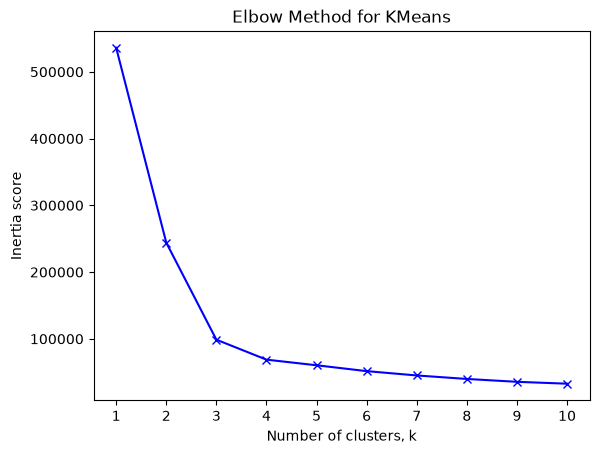

In [14]:
#plot inertia
inertia_scores = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
    kmeans.fit(X)
    inertia_scores.append(kmeans.inertia_)

plt.plot(k_values, inertia_scores, "bx-")
plt.xlabel("Number of clusters, k")
plt.ylabel("Inertia score")
plt.title("Elbow Method for KMeans")
plt.xticks(k_values)
plt.show()

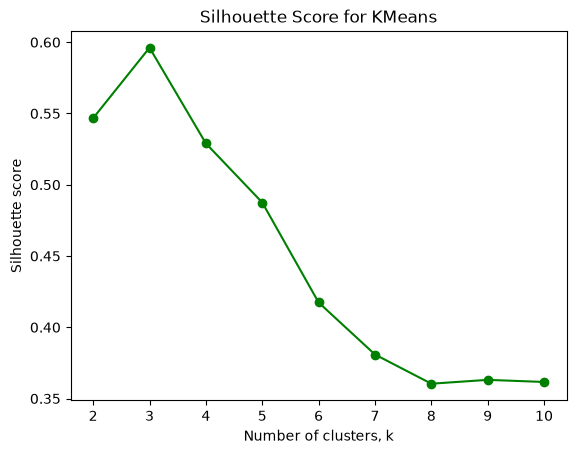

In [15]:
#plot silhouette

silhouette_scores = []
k_values = range(2, 11)  # silhouette cannot be used with k=1

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
    kmeans.fit(X)

    labels = kmeans.labels_
    score = silhouette_score(X, labels)

    silhouette_scores.append(score)

plt.plot(k_values, silhouette_scores, "go-")
plt.xlabel("Number of clusters, k")
plt.ylabel("Silhouette score")
plt.title("Silhouette Score for KMeans")
plt.xticks(k_values)
plt.show()

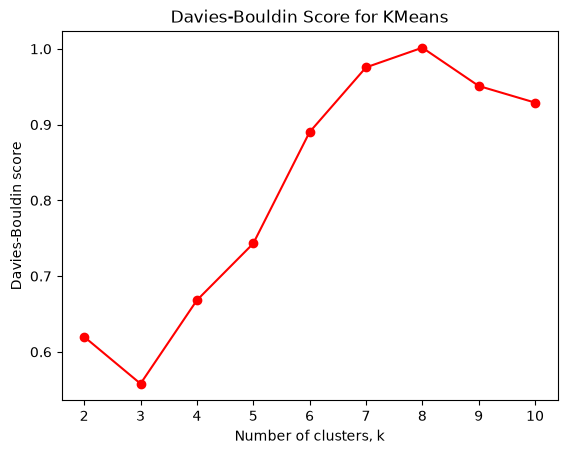

In [16]:
#plot Davies-Bouldin score
davies_bouldin_scores = []
k_values = range(2, 11)  # Davies-Bouldin cannot be used with k=1

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
    kmeans.fit(X)

    labels = kmeans.labels_
    score = davies_bouldin_score(X, labels)

    davies_bouldin_scores.append(score)

plt.plot(k_values, davies_bouldin_scores, "ro-")
plt.xlabel("Number of clusters, k")
plt.ylabel("Davies-Bouldin score")
plt.title("Davies-Bouldin Score for KMeans")
plt.xticks(k_values)
plt.show()